In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('../src')

from data_processing import DataLoader, DataCleaner
from visualization.plots import plot_keyword_frequency

In [2]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Initialize loader
loader = DataLoader('../config.yaml')

# Load raw data
df = loader.load_raw_data('../data/raw/consumer_complaints.csv')

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

df.head()

INFO:data_processing.data_loader:Loading data from ../data/raw/consumer_complaints.csv
INFO:data_processing.data_loader:Successfully loaded 1046669 records


Loaded: 1046669 rows, 18 columns


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,12/28/25,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt was result of identity theft,"I do not recognize the aforementioned accounts, collections, or hard inquiries as reported. The ...",Company has responded to the consumer and the CFPB and chooses not to provide a public response,"I.C. System, Inc.",IN,46201,NaN,Consent provided,Web,12/28/25,Closed with explanation,Yes,NaN,18327208.0
1,09/26/25,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,"I am writing pursuant to the Fair Credit Reporting Act ( FCRA ), particularly Section 605B [ 15 ...",NaN,"EQUIFAX, INC.",LA,71457,NaN,Consent provided,Web,09/26/25,Closed with non-monetary relief,Yes,NaN,16207045.0
2,03/15/25,Checking or savings account,Checking account,Managing an account,Deposits and withdrawals,I am writing to formally dispute several unauthorized transactions on my account that occurred a...,NaN,TD BANK US HOLDING COMPANY,MA,01803,NaN,Consent provided,Web,03/15/25,Closed with explanation,Yes,NaN,12493914.0
3,2005-03-25,Debt collection,Other debt,Attempts to collect debt not owed,Debt was result of identity theft,"I am sending this asking for your help to file a formal complaint against XXXX, XXXX XXXX XXXX r...",NaN,"Portfolio Recovery Associates, LLC",TX,77373,NaN,Consent provided,Web,2005-03-25,Closed with non-monetary relief,Yes,NaN,13317604.0
4,04/29/25,Credit reporting or other personal consumer reports,Credit reporting,Improper use of your report,Reporting company used your report improperly,"Upon reviewing my consumer reports, l discovered some instances of late payments on an account f...",Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NJ,08016,NaN,Consent provided,Web,04/29/25,Closed with non-monetary relief,Yes,NaN,13232751.0


In [4]:
df_original = df.copy()

# Handle missing complaint narratives
text_col = 'Consumer complaint narrative'

print(f"\nMissing narratives: {df[text_col].isna().sum()}")

# Remove rows without complaint text
df = df[df[text_col].notna()].copy()

print(f"After removing nulls: {df.shape}")


Missing narratives: 1022038
After removing nulls: (24631, 18)


In [5]:
# Clean complaint text
def clean_complaint_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text)
    
    # 1. Remove masked data (XXXX patterns)
    text = re.sub(r'\bX{2,}\b', '', text) # XXXX -> space
    text = re.sub(r'\{X{2,}\}', '', text) # {XXXX} -> space
    
    # 2. Remove incomplete references [15 ...
    text = re.sub(r'\[\s*\d+\s*\.{2,}\s*\]?', '', text)
    
    # 3. Clean excessive whitespace (but keep single spaces)
    text = ' '.join(text.split())
    
    # 4. Strip leading/trailing whitespace
    text = text.strip()
    
    return text

In [6]:
import re

In [7]:
# Apply cleaning
df['complaint_clean'] = df[text_col].apply(clean_complaint_text)

# Show example
print("BEFORE CLEANING:")
print(df[text_col].iloc[3][:300])
print("AFTER CLEANING:")
print(df['complaint_clean'].iloc[3][:300])

BEFORE CLEANING:
I am sending this asking for your help to file a formal complaint against XXXX, XXXX XXXX XXXX regarding an account I have with them XXXXXXXX XXXX XXXX I believe that this account needs to be removed from my credit report due to error, fraud, and be remove. Here are the details of my complaint : XXX
AFTER CLEANING:
I am sending this asking for your help to file a formal complaint against , regarding an account I have with them I believe that this account needs to be removed from my credit report due to error, fraud, and be remove. Here are the details of my complaint : ( Original Creditor : ) Balance : {$1700.


In [8]:
# Create text features
df['char_count'] = df['complaint_clean'].str.len()
df['word_count'] = df['complaint_clean'].str.split().str.len()
df['sentence_count'] = df['complaint_clean'].str.count(r'[.!?]+')

# Flag truncated text
df['is_truncated'] = df[text_col].str.endswith('...', na=False)

# Summary stats
print("\nText Statistics:")
print(df[['char_count', 'word_count', 'sentence_count']].describe())


Text Statistics:
         char_count    word_count  sentence_count
count  24631.000000  24631.000000    24631.000000
mean    1002.543786    168.247087       10.670050
std     1182.174648    196.844398       14.048561
min        0.000000      0.000000        0.000000
25%      338.000000     58.000000        4.000000
50%      680.000000    116.000000        7.000000
75%     1221.000000    207.000000       13.000000
max    28978.000000   5291.000000      489.000000


In [9]:
# Filter short complaints
min_words = 10

print(f"\nComplaints with < {min_words} words: {(df['word_count'] < min_words).sum()}")

df = df[df['word_count'] >= min_words].copy()

print(f"After filtering: {df.shape}")


Complaints with < 10 words: 220
After filtering: (24411, 23)


In [10]:
# Clean date fields
df['Date received'] = pd.to_datetime(df['Date received'], format='%m/%d/%y', errors='coerce')
df['Date sent to company'] = pd.to_datetime(df['Date sent to company'], format='%m/%d/%y', errors='coerce')

# Extract date features
df['year'] = df['Date received'].dt.year
df['month'] = df['Date received'].dt.month
df['month_name'] = df['Date received'].dt.month_name()
df['day_of_week'] = df['Date received'].dt.day_name()

In [11]:
# Clean categorical fields
# Product - Title case
df['Product'] = df['Product'].str.strip().str.title()

# Company - Uppercase
df['Company'] = df['Company'].str.upper().str.strip()

# State - Uppercase, 2 letters
df['State'] = df['State'].str.upper().str.strip()

# Fill missing values
df['Company public response'] = df['Company public response'].fillna('No public response')
df['ZIP code'] = df['ZIP code'].fillna('00000')
df['Tags'] = df['Tags'].fillna('No tags')


In [12]:
# Select columns to keep
columns_to_keep = [
    'Date received',
    'year',
    'month',
    'month_name',
    'day_of_week',
    'Product',
    'Sub-product',
    'Issue',
    'Sub-issue',
    'Company',
    'State',
    'Company response to consumer',
    'Timely response?',
    'Consumer disputed?',
    'complaint_clean',
    'char_count',
    'word_count',
    'sentence_count',
    'is_truncated'
]

df_processed = df[columns_to_keep].copy()

print(f"\nFinal processed dataset: {df_processed.shape}")


Final processed dataset: (24411, 19)


In [13]:
# Save processed data 
df_processed.to_csv('../data/processed/consumer_complaints_processed.csv', index=False)

In [14]:
summary = {
    'Original records': len(df_original),
    'After removing null narratives': len(df),
    'After filtering short complaints': len(df_processed),
    'Records removed': len(df_original) - len(df_processed),
    'Removal rate': f"{((len(df_original) - len(df_processed)) / len(df_original) * 100):.2f}%",
    '': '',
    'Average characters': f"{df_processed['char_count'].mean():.0f}",
    'Average words': f"{df_processed['word_count'].mean():.0f}",
    'Average sentences': f"{df_processed['sentence_count'].mean():.1f}",
    ' ': '',
    'Truncated complaints': df_processed['is_truncated'].sum(),
    'Unique products': df_processed['Product'].nunique(),
    'Unique companies': df_processed['Company'].nunique(),
    'Date range': f"{df_processed['Date received'].min()} to {df_processed['Date received'].max()}"
}

for key, value in summary.items():
    print(f"{key:.<40} {value}")

Original records........................ 1046669
After removing null narratives.......... 24411
After filtering short complaints........ 24411
Records removed......................... 1022258
Removal rate............................ 97.67%
........................................ 
Average characters...................... 1011
Average words........................... 170
Average sentences....................... 10.8
 ....................................... 
Truncated complaints.................... 20
Unique products......................... 11
Unique companies........................ 778
Date range.............................. 2025-01-20 00:00:00 to 2026-01-14 00:00:00


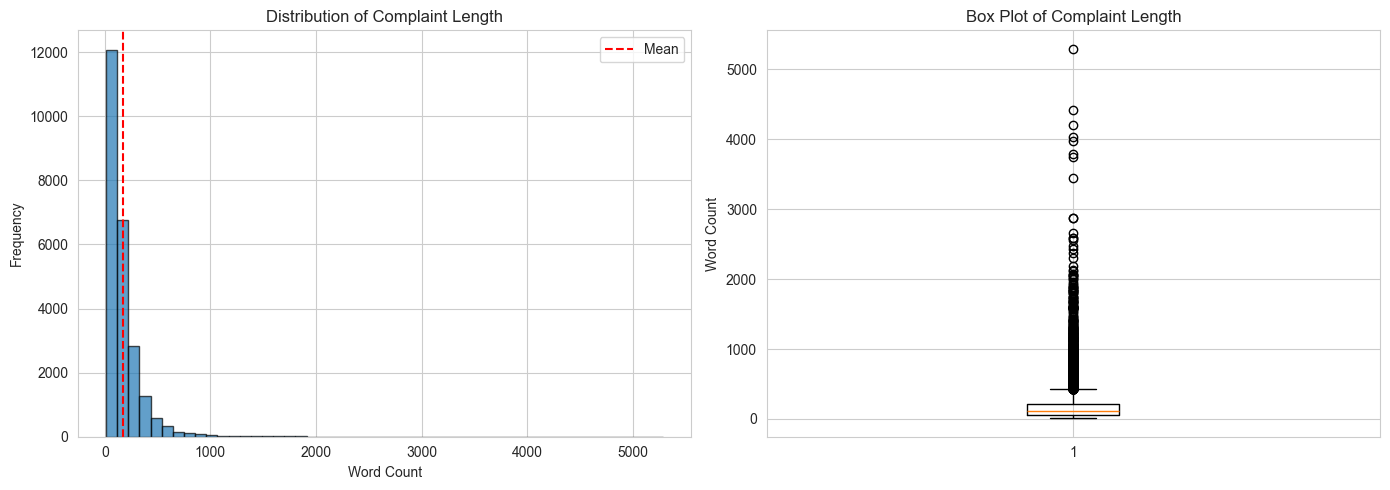

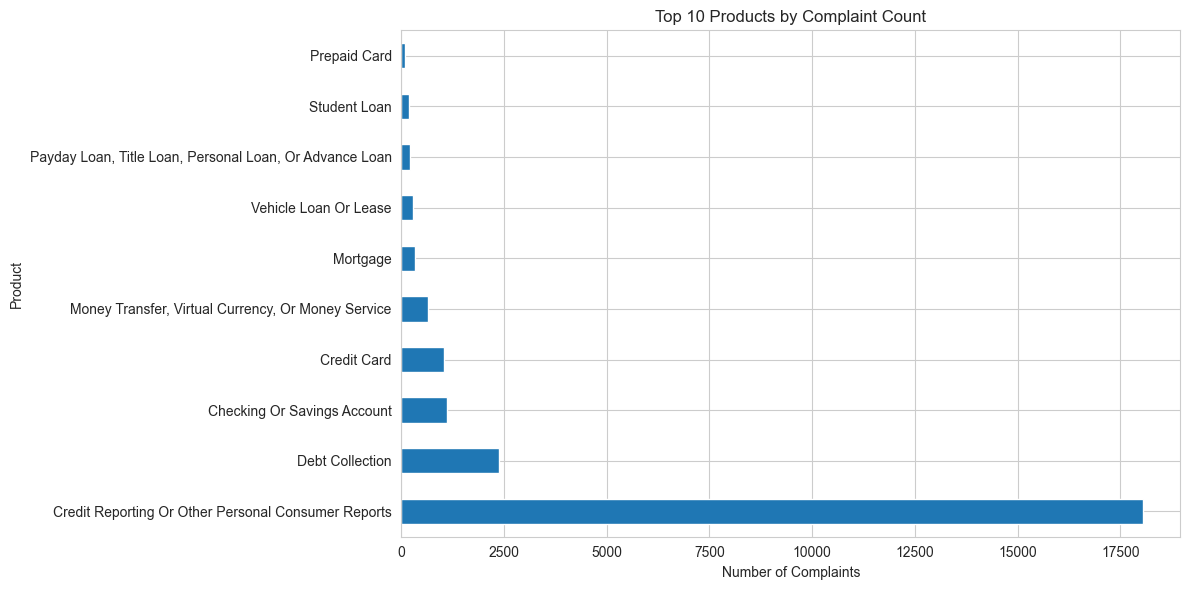

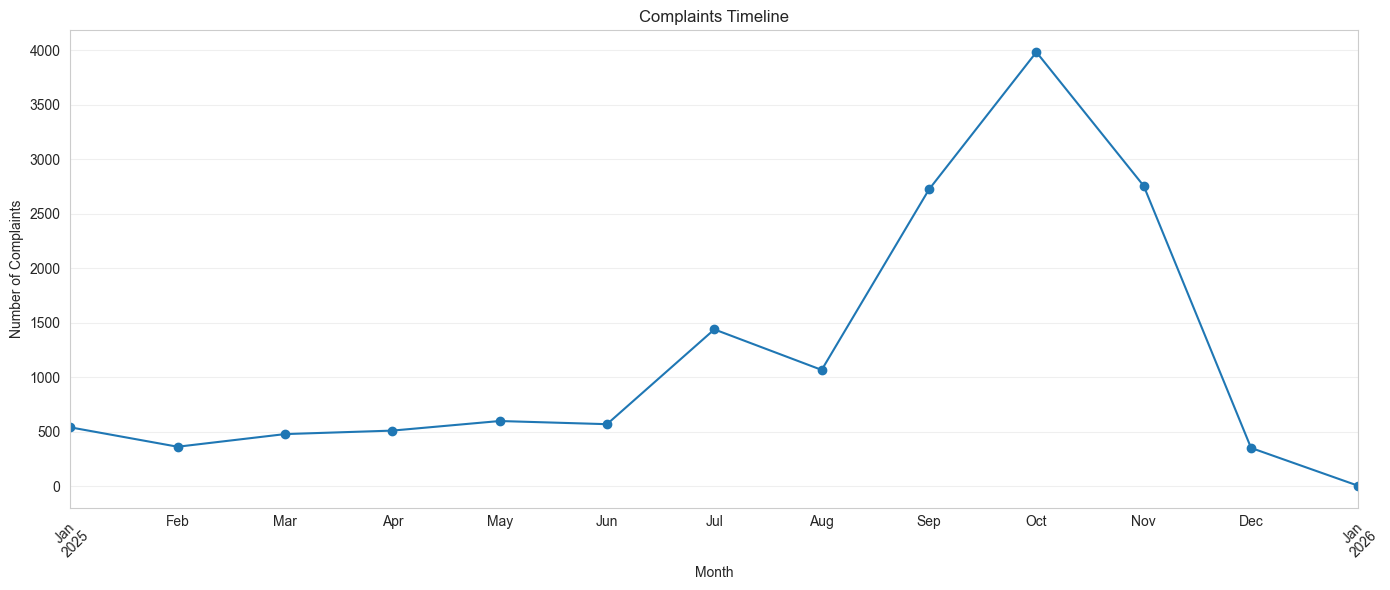

SAMPLE COMPARISONS - Before vs After Cleaning

--- Sample 1 ---
BEFORE:
I do not recognize the aforementioned accounts, collections, or hard inquiries as reported. The aforementioned accounts, collections, and hard inquiries appearing on my consumer credit report maintain...

AFTER:
I do not recognize the aforementioned accounts, collections, or hard inquiries as reported. The aforementioned accounts, collections, and hard inquiries appearing on my consumer credit report maintain...
--------------------------------------------------------------------------------

--- Sample 2 ---
BEFORE:
I am writing pursuant to the Fair Credit Reporting Act ( FCRA ), particularly Section 605B [ 15 U.S. Code 1681c2 ], which mandates that consumer reporting agencies must block and remove all informatio...

AFTER:
I am writing pursuant to the Fair Credit Reporting Act ( FCRA ), particularly Section 605B [ 15 U.S. Code 1681c2 ], which mandates that consumer reporting agencies must block and remove all inf

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. TEXT LENGTH DISTRIBUTION
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_processed['word_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Complaint Length')
axes[0].axvline(df_processed['word_count'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

axes[1].boxplot(df_processed['word_count'])
axes[1].set_ylabel('Word Count')
axes[1].set_title('Box Plot of Complaint Length')

plt.tight_layout()
plt.savefig('../outputs/figures/text_length_after_cleaning.png', dpi=300)
plt.show()

# 2. TOP PRODUCTS
top_products = df_processed['Product'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_products.plot(kind='barh')
plt.xlabel('Number of Complaints')
plt.title('Top 10 Products by Complaint Count')
plt.tight_layout()
plt.savefig('../outputs/figures/top_products_cleaned.png', dpi=300)
plt.show()

# 3. COMPLAINTS OVER TIME
monthly = df_processed.groupby(df_processed['Date received'].dt.to_period('M')).size()

plt.figure(figsize=(14, 6))
monthly.plot(kind='line', marker='o')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.title('Complaints Timeline')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/complaints_timeline.png', dpi=300)
plt.show()

# 4. BEFORE/AFTER COMPARISON
print("SAMPLE COMPARISONS - Before vs After Cleaning")

for i in range(3):
    print(f"\n--- Sample {i+1} ---")
    print("BEFORE:")
    print(df[text_col].iloc[i][:200] + "...")
    print("\nAFTER:")
    print(df_processed['complaint_clean'].iloc[i][:200] + "...")
    print("-"*80)